# Introduction

GLP-1 medications such as Ozempic and Wegovy have rapidly transformed public conversations about weight loss, prevention, and personal responsibility. Their rise has generated intense public interest, framed simultaneously as a breakthrough in medical treatment, a cultural phenomenon, and a challenge to long-standing behavioral models of self-regulation. At the same time, traditional weight-loss communities—often centered on slow, effortful lifestyle change—continue to reflect a very different set of narratives about motivation, struggle, and agency.

These divergent discourses present an opportunity to explore how people understand **responsibility**, **agency**, and **the future** in the context of preventive health. This project uses YouTube comments as a large-scale, naturalistic data source to examine these patterns through the lens of a developing theoretical framework I call **Generalized Temporal Responsibility (GTR)**.

GTR proposes that preventive behavior is shaped by a cross-domain pattern of how individuals balance:
- **Agency** (“Can I do this?”)
- **Responsibility** (“Should I do this?”)
- **Future orientation** (“Why does it matter long-term?”)
- **Cognitive scarcity** (limited executive bandwidth)

According to GTR, these dimensions vary across individuals and contexts, shaping how people approach preventive actions in domains such as health, finances, and social behavior. This study applies these ideas to real-world language, beginning with theoretically grounded expectations about how these dimensions should appear in different communities and then empirically testing whether those expectations hold.

Social media, including YouTube, provide a rich, emotionally expressive discourse that reveals how people frame their struggles, decisions, and expectations in their own words. By comparing GLP-1-related videos with traditional weight-loss journey videos, this project investigates how online communities differ in their expressions of responsibility, temporal thinking, and perceived cognitive burden. These empirical patterns help evaluate whether GTR provides a useful structure for understanding the evolving landscape of preventive health behavior.


# Methods

## Data Collection
This project collected YouTube comments from two categories of videos:

1. **GLP-1–related videos** (e.g., Ozempic, Wegovy)
2. **Traditional “weight-loss journey” videos** focused on lifestyle change

Videos were identified using the YouTube Data API v3 with search queries such as:
- “Ozempic weight loss story”
- “Starting my weight loss journey”

From these search results, videos with **≥ 300 comments** were selected to ensure meaningful discussion volume.  
A total of **28 videos** met criteria and were included.

Comments were collected using a custom Python function that iterated through all available comment pages (within a global safety cap to prevent API overuse).  
This produced a final dataset of:

- **8,932 GLP-1 comments**
- **7,331 Journey comments**
- **Total = 16,263 comments**

All API keys were secured, and no personally identifiable information was collected or stored.

---

## Data Cleaning
Each comment was cleaned through:
- Lowercasing
- Removing URLs, emojis, and extra whitespace
- Converting Unicode characters to plain text
- Standardizing apostrophes and contractions

A new column **`text_clean`** stored the processed comment for analysis.

---

## Lexicon Construction
To operationalize GTR, four lexicons were developed:

- **Agency** (e.g., “i can”, “able to”, “i can’t”)
- **Responsibility** (e.g., “i should”, “i need to”, “supposed to”)
- **Future Orientation** (e.g., “future”, “years from now”, “long term”)
- **Scarcity / Cognitive Load** (e.g., “overwhelmed”, “too much”, “can’t handle”)

A helper function counted lexicon occurrences per comment.

---

## Statistical Analysis
To compare GLP-1 vs Journey discourse:

- Lexicon counts were converted into **binary indicators** (“appears at least once”).
- **Two-proportion Z-tests** assessed differences in prevalence between groups.
- Effect sizes were interpreted relative to GTR predictions.

---

## Qualitative KWIC Analysis
For deeper narrative understanding, **Key Word In Context (KWIC)** searches were performed.  
The KWIC tool returned ~10 example contexts per group for target phrases:
- “I should”
- “future”
- “I can”
- “overwhelmed”

These samples allowed qualitative comparison of meaning, tone, and narrative style across discourse communities.

---

### Theoretical Expectations Prior to Analysis
Before conducting the empirical analysis, I held several theory-driven expectations based on the GTR framework and prior behavioral science literature: (1) that responsibility, agency, and future-oriented language would appear more frequently in weight-loss journey comments, reflecting the self-regulatory nature of lifestyle change; and (2) that scarcity or overwhelm would be more common in GLP-1 discourse due to the emotional load of medical decision-making. The analysis below evaluates these expectations against the observed linguistic patterns in the YouTube data.


#1.  Imports and basic set up

In [1]:
# CELL 1 — Setup YouTube API client

!pip install --quiet google-api-python-client

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from googleapiclient.discovery import build

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

# 🔑 Put your YouTube API key here (keep private!)
# API_KEY = "DELETED"  # <-- replace with key as a string

# youtube = build("youtube", "v3", developerKey=API_KEY)
# print("YouTube client initialized.")

print("Notebook ready — using CSV data only.")



Notebook ready — using CSV data only.


#1.5 Load using .csv

In [3]:
# Load saved YouTube comments (instead of scraping)
CSV_PATH = "module_07.csv"

yt_df = pd.read_csv(CSV_PATH)
yt_df["text"] = yt_df["text"].astype(str)
yt_df["text_clean"] = yt_df["text"].str.lower()

print("Loaded", len(yt_df), "comments from CSV")
yt_df.head()


Loaded 16263 comments from CSV


,date,author,text,likes,video_id,group,topic,text_clean
0,2025-11-05T07:21:42Z,@sandina8581,Why would anyone do this to their bodies? My G...,1,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...,why would anyone do this to their bodies? my g...
1,2025-11-01T02:30:15Z,@54lex,I just started on ozempic for my type 2 diabet...,0,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...,i just started on ozempic for my type 2 diabet...
2,2025-09-10T02:20:17Z,@EdwardJackson-u9z,These people never really learned to change th...,0,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...,these people never really learned to change th...
3,2025-09-08T04:49:52Z,@dianelittle3040,They want you to keep buying it. There are sev...,0,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...,they want you to keep buying it. there are sev...
4,2025-07-27T20:38:05Z,@JacobitoBello27,"Looks like when taking ozempic, you also need ...",0,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...,"looks like when taking ozempic, you also need ..."


#2.  Search helper for videos

In [2]:
# CELL 2 — Helper to search for videos by keyword

# def search_videos(query, max_results=10):
#     """
#     Search YouTube for videos matching a query.
#     Returns a DataFrame with video_id, title, channel, published date.
#     """
#     resp = youtube.search().list(
#         part="snippet",
#         q=query,
#         maxResults=max_results,
#         type="video"
#     ).execute()

#     rows = []
#     for item in resp.get("items", []):
#         vid = item["id"]["videoId"]
#         sn = item["snippet"]
#         rows.append({
#             "video_id": vid,
#             "title": sn["title"],
#             "channel": sn["channelTitle"],
#             "publishedAt": sn["publishedAt"]
#         })
#     return pd.DataFrame(rows)


#3.  Find GLP-1 and "journey" videos

In [3]:
# CELL 3 - search queries for GLP-1 and journey videos
# glp_query = "Ozempic weight loss story"
# journey_query = "starting my weight loss journey"

# glp_candidates = search_videos(glp_query, max_results=25)
# journey_candidates = search_videos(journey_query, max_results=25)

# print("GLP-1 candidates:")
# display(glp_candidates)

# print("\nJourney candidates:")
# display(journey_candidates)


GLP-1 candidates:


,video_id,title,channel,publishedAt
0,6u4TbqFZjO8,What’s it like taking Ozempic? Patients share ...,TODAY,2023-02-15T14:30:01Z
1,W-qxyGT0CPs,Weight loss breakthrough or hype? Examining We...,CBS Austin,2023-05-12T20:45:38Z
2,IztL9CiqUFs,How Mounjaro and Ozempic Transformed These Wom...,Inside Edition,2025-01-04T13:04:31Z
3,E_1k59l-Kbk,Why Aren&#39;t I Losing Weight on Ozempic?,Watkins Metabolic Clinic,2023-06-11T16:41:20Z
4,laPaezEsteI,Ozempic is a game-changer. Here’s how it works.,Vox,2023-03-14T12:00:36Z
5,_GPtQbeWW5Q,You&#39;re Being Lied To About Ozempic | Truth...,Business Insider,2024-11-13T16:00:35Z
6,QDYQ_4gsiOU,Oprah on why she turned to weight loss drugs,CNN,2024-03-21T02:23:06Z
7,_rXANcA01C0,This is what happens when you stop taking Ozempic,Good Morning America,2023-02-01T17:23:34Z
8,RuHDMRM9V-U,How long does it take?(#wegovy video 7/12) #we...,"Christopher McGowan, MD",2023-05-01T17:43:37Z
9,EJZ5l8t-yhA,Ozempic offers hope to those struggling to los...,ABC News,2023-12-22T09:52:47Z



Journey candidates:


,video_id,title,channel,publishedAt
0,UdjbsLICSrI,WAYS TO START YOUR WEIGHT LOSS JOURNEY (THE PE...,Brix Fitness,2024-04-14T15:12:17Z
1,bCeMX6Zxb4w,If I Had to Start My Weight Loss Journey Over....,Nikki Gets Fit,2025-07-25T01:30:08Z
2,aLxoeCeJFyI,The BEST Fat Loss Diet,KenDBerryMD,2024-09-25T19:00:33Z
3,rUk5ZAXc2K0,How To Start Your Weight Loss Journey | ACTUAL...,Nikki Gets Fit,2025-01-02T23:54:36Z
4,9bscSY_FOOA,Calorie Deficit Hacks,Alex Solomin,2023-06-25T17:12:50Z
5,bXtnPJg8s8s,My weight loss transformation,Alivia D'Andrea,2021-05-19T16:19:26Z
6,OElXGvMF_VQ,STARTING MY WEIGHT LOSS JOURNEY: That&#39;s It...,Beatrice Caruso,2020-04-19T00:52:30Z
7,5Rp0ZkLX27o,WHAT I WISH I KNEW BEFORE LOSING 75+ LBS| Tips...,Maya Graves,2025-05-26T20:41:52Z
8,5s_wTTj3y4A,The REAL Reason I Started My Weight Loss Journey,Jasmin Flowers,2025-04-19T00:42:16Z
9,HOuegROjby4,Fat to muscular in 15 months,okaymohit,2022-08-08T06:21:27Z


#4.  Get comment counts for videos

In [4]:
# CODE 4 — Get comment counts for candidate videos

# def get_video_comment_count(video_id):
#     resp = youtube.videos().list(
#         part="statistics,snippet",
#         id=video_id
#     ).execute()

#     items = resp.get("items", [])
#     if not items:
#         return None, None, None, None

#     stats = items[0].get("statistics", {})
#     snippet = items[0].get("snippet", {})

#     return (
#         snippet.get("title", ""),
#         snippet.get("channelTitle", ""),
#         snippet.get("publishedAt", ""),
#         int(stats.get("commentCount", 0))
#     )

# def compute_comment_counts(df, group_label):
#     rows = []
#     for _, row in df.iterrows():
#         vid = row["video_id"]
#         title, channel, published, count = get_video_comment_count(vid)
#         rows.append({
#             "video_id": vid,
#             "title": title,
#             "channel": channel,
#             "publishedAt": published,
#             "comment_count": count,
#             "group": group_label
#         })
#     return pd.DataFrame(rows)



#5. Compute comment counts

In [5]:
# CODE 5 — Compute comment counts for GLP-1 and journey candidates

# glp_counts = compute_comment_counts(glp_candidates, "glp1")
# journey_counts = compute_comment_counts(journey_candidates, "journey")

# comment_df = pd.concat([glp_counts, journey_counts], ignore_index=True)
# comment_df


,video_id,title,channel,publishedAt,comment_count,group
0,6u4TbqFZjO8,What’s it like taking Ozempic? Patients share ...,TODAY,2023-02-15T14:30:01Z,415,glp1
1,W-qxyGT0CPs,Weight loss breakthrough or hype? Examining We...,CBS Austin,2023-05-12T20:45:38Z,269,glp1
2,IztL9CiqUFs,How Mounjaro and Ozempic Transformed These Wom...,Inside Edition,2025-01-04T13:04:31Z,100,glp1
3,E_1k59l-Kbk,Why Aren't I Losing Weight on Ozempic?,Watkins Metabolic Clinic,2023-06-11T16:41:20Z,393,glp1
4,laPaezEsteI,Ozempic is a game-changer. Here’s how it works.,Vox,2023-03-14T12:00:36Z,2694,glp1
5,_GPtQbeWW5Q,You're Being Lied To About Ozempic | Truth Com...,Business Insider,2024-11-13T16:00:35Z,3059,glp1
6,QDYQ_4gsiOU,Oprah on why she turned to weight loss drugs,CNN,2024-03-21T02:23:06Z,685,glp1
7,_rXANcA01C0,This is what happens when you stop taking Ozempic,Good Morning America,2023-02-01T17:23:34Z,4624,glp1
8,RuHDMRM9V-U,How long does it take?(#wegovy video 7/12) #we...,"Christopher McGowan, MD",2023-05-01T17:43:37Z,510,glp1
9,EJZ5l8t-yhA,Ozempic offers hope to those struggling to los...,ABC News,2023-12-22T09:52:47Z,126,glp1


#5.5 Select videos with enough comments for scraping

In [6]:
# CELL 5.5 — Select videos with enough comments for scraping

# threshold = 300  # adjust as needed

# good_videos = comment_df[comment_df["comment_count"] >= threshold].copy()
# print("Videos selected for scraping:")
# display(good_videos)

# # Build the video_configs list automatically
# video_configs = [
#     {
#         "video_id": row.video_id,
#         "label": row.group,
#         "topic": row.title[:80]  # keep topic short
#     }
#     for _, row in good_videos.iterrows()
# ]

# video_configs


Videos selected for scraping:


,video_id,title,channel,publishedAt,comment_count,group
0,6u4TbqFZjO8,What’s it like taking Ozempic? Patients share ...,TODAY,2023-02-15T14:30:01Z,415,glp1
3,E_1k59l-Kbk,Why Aren't I Losing Weight on Ozempic?,Watkins Metabolic Clinic,2023-06-11T16:41:20Z,393,glp1
4,laPaezEsteI,Ozempic is a game-changer. Here’s how it works.,Vox,2023-03-14T12:00:36Z,2694,glp1
5,_GPtQbeWW5Q,You're Being Lied To About Ozempic | Truth Com...,Business Insider,2024-11-13T16:00:35Z,3059,glp1
6,QDYQ_4gsiOU,Oprah on why she turned to weight loss drugs,CNN,2024-03-21T02:23:06Z,685,glp1
7,_rXANcA01C0,This is what happens when you stop taking Ozempic,Good Morning America,2023-02-01T17:23:34Z,4624,glp1
8,RuHDMRM9V-U,How long does it take?(#wegovy video 7/12) #we...,"Christopher McGowan, MD",2023-05-01T17:43:37Z,510,glp1
10,nW47Qw8FV8U,The Many Lies About The Ozempic Weight Loss Craze,Doctor Mike,2023-03-19T14:00:22Z,5525,glp1
11,h8q0VeE0NpY,"Ozempic, Mounjaro users talk about changes to ...",ABC News,2024-03-01T13:28:06Z,3063,glp1
12,WNr8uLIopCs,4 Facts About Weight Loss and Ozempic You Must...,Doctor Youn,2025-03-08T17:03:49Z,341,glp1


[{'video_id': '6u4TbqFZjO8',
  'label': 'glp1',
  'topic': 'What’s it like taking Ozempic? Patients share their stories'},
 {'video_id': 'E_1k59l-Kbk',
  'label': 'glp1',
  'topic': "Why Aren't I Losing Weight on Ozempic?"},
 {'video_id': 'laPaezEsteI',
  'label': 'glp1',
  'topic': 'Ozempic is a game-changer. Here’s how it works.'},
 {'video_id': '_GPtQbeWW5Q',
  'label': 'glp1',
  'topic': "You're Being Lied To About Ozempic | Truth Complex | Business Insider"},
 {'video_id': 'QDYQ_4gsiOU',
  'label': 'glp1',
  'topic': 'Oprah on why she turned to weight loss drugs'},
 {'video_id': '_rXANcA01C0',
  'label': 'glp1',
  'topic': 'This is what happens when you stop taking Ozempic'},
 {'video_id': 'RuHDMRM9V-U',
  'label': 'glp1',
  'topic': 'How long does it take?(#wegovy video 7/12) #weightloss #weightlossjourney #ozemp'},
 {'video_id': 'nW47Qw8FV8U',
  'label': 'glp1',
  'topic': 'The Many Lies About The Ozempic Weight Loss Craze'},
 {'video_id': 'h8q0VeE0NpY',
  'label': 'glp1',
  'to

#6. Function to pull comments from one video

In [7]:
# CELL 6 — Pull comments for single video

# def get_comments_for_video(video_id, group_label, topic_label, max_comments=1000):
#     comments = []
#     next_page_token = None

#     while True:
#         resp = youtube.commentThreads().list(
#             part="snippet",
#             videoId=video_id,
#             pageToken=next_page_token,
#             maxResults=100,
#             textFormat="plainText"
#         ).execute()

#         for item in resp.get("items", []):
#             sn = item["snippet"]["topLevelComment"]["snippet"]
#             comments.append({
#                 "date": sn["publishedAt"],
#                 "author": sn.get("authorDisplayName", ""),
#                 "text": sn["textDisplay"],
#                 "likes": sn.get("likeCount", 0),
#                 "video_id": video_id,
#                 "group": group_label,
#                 "topic": topic_label
#             })

#         next_page_token = resp.get("nextPageToken")

#         if not next_page_token or len(comments) >= max_comments:
#             break

#     return pd.DataFrame(comments)


#6.5  Add global limit constant

In [8]:
# GLOBAL LIMIT — Safety default for first run
# MAX_COMMENTS_PER_VIDEO = 600   # raise this later (1000, 1500, etc.)


#7.  Pull comments for all videos -> Build dataset

In [9]:
# CELL 7 — Collect comments for all GLP-1 + journey videos

# all_dfs = []

# for cfg in video_configs:
#     print(f"Fetching comments for video {cfg['video_id']} ({cfg['topic']})...")
#     df_vid = get_comments_for_video(
#         video_id=cfg["video_id"],
#         group_label=cfg["label"],
#         topic_label=cfg["topic"],
#         max_comments=MAX_COMMENTS_PER_VIDEO  # adjust if needed
#     )
#     print(f"  Got {len(df_vid)} comments.")
#     all_dfs.append(df_vid)

# yt_df = pd.concat(all_dfs, ignore_index=True)
# print(f"\nTotal comments collected: {len(yt_df)}")
# yt_df.head()


Fetching comments for video 6u4TbqFZjO8 (What’s it like taking Ozempic? Patients share their stories)...
  Got 243 comments.
Fetching comments for video E_1k59l-Kbk (Why Aren't I Losing Weight on Ozempic?)...
  Got 98 comments.
Fetching comments for video laPaezEsteI (Ozempic is a game-changer. Here’s how it works.)...
  Got 600 comments.
Fetching comments for video _GPtQbeWW5Q (You're Being Lied To About Ozempic | Truth Complex | Business Insider)...
  Got 600 comments.
Fetching comments for video QDYQ_4gsiOU (Oprah on why she turned to weight loss drugs)...
  Got 423 comments.
Fetching comments for video _rXANcA01C0 (This is what happens when you stop taking Ozempic)...
  Got 600 comments.
Fetching comments for video RuHDMRM9V-U (How long does it take?(#wegovy video 7/12) #weightloss #weightlossjourney #ozemp)...
  Got 221 comments.
Fetching comments for video nW47Qw8FV8U (The Many Lies About The Ozempic Weight Loss Craze)...
  Got 600 comments.
Fetching comments for video h8q0VeE0Np

,date,author,text,likes,video_id,group,topic
0,2025-11-05T07:21:42Z,@sandina8581,Why would anyone do this to their bodies? My G...,1,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...
1,2025-11-01T02:30:15Z,@54lex,I just started on ozempic for my type 2 diabet...,0,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...
2,2025-09-10T02:20:17Z,@EdwardJackson-u9z,These people never really learned to change th...,0,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...
3,2025-09-08T04:49:52Z,@dianelittle3040,They want you to keep buying it. There are sev...,0,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...
4,2025-07-27T20:38:05Z,@JacobitoBello27,"Looks like when taking ozempic, you also need ...",0,6u4TbqFZjO8,glp1,What’s it like taking Ozempic? Patients share ...


#7.25 Text cleaning

In [4]:
# CLEAN TEXT COLUMN — REQUIRED before GTR counts

# ensure text column is string
yt_df['text'] = yt_df['text'].astype(str)

# create lowercase cleaned text for counting phrases
yt_df['text_clean'] = yt_df['text'].str.lower()

# sanity check
yt_df[['text', 'text_clean']].head()


,text,text_clean
0,Why would anyone do this to their bodies? My G...,why would anyone do this to their bodies? my g...
1,I just started on ozempic for my type 2 diabet...,i just started on ozempic for my type 2 diabet...
2,These people never really learned to change th...,these people never really learned to change th...
3,They want you to keep buying it. There are sev...,they want you to keep buying it. there are sev...
4,"Looks like when taking ozempic, you also need ...","looks like when taking ozempic, you also need ..."


#7.5  Comparison

In [5]:
# CELL 7.5 — Split into GLP-1 and journey groups, include basic stats

glp_df = yt_df[yt_df['group'] == 'glp1'].copy()
journey_df = yt_df[yt_df['group'] == 'journey'].copy()

print("GLP-1 comments:", len(glp_df))
print("Journey comments:", len(journey_df))

print("\nSample GLP-1 comments:")
print(glp_df[['topic', 'text']].head(5).to_string(index=False))

print("\nSample Journey comments:")
print(journey_df[['topic', 'text']].head(5).to_string(index=False))


GLP-1 comments: 8932
Journey comments: 7331

Sample GLP-1 comments:
                                                      topic                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

#8. Define lexicons (agency, responsibility, future, scarcity)

In [6]:
# CELL 8 — define simple lexicons for GTR dimensions

# CELL 8 — modify to expanded lexicons for GTR dimensions

agency_words = [
    "i can ", "i'm able", "im able", "i managed", "i did it",
    "i tried", "i handled", "i decided", "i committed", "i overcame",
    "i will ", "i'll keep", "i'll try", "able to", "manage", "stick to"
]

responsibility_words = [
    "i should", "i need to", "i ought to", "supposed to",
    "have to", "i have to", "i must", "my fault", "on me",
    "responsible", "my responsibility"
]

future_words = [
    "future", "long term", "long-term", "years from now", "later on",
    "in the long run", "down the road", "down the line", "eventually",
    "next year", "in a year", "my goal is", "my goals are", "goal weight"
]

scarcity_words = [
    "overwhelmed", "overwhelm", "exhausted", "tired", "burnt out",
    "burned out", "no time", "too busy", "too much", "can't focus",
    "stressed", "stressed out", "frustrated", "drained", "worn out"
]

def count_phrases(text, phrases):
    text = text.lower()
    return sum(text.count(p) for p in phrases)




#9.  Apply GTR to each group

In [7]:
# CELL 9 — Add GTR + scarcity counts to GLP-1 and journey comments

def add_gtr_counts(df_subset):
    subset = df_subset.copy()
    subset['agency_count']   = subset['text_clean'].apply(lambda t: count_phrases(t, agency_words))
    subset['resp_count']     = subset['text_clean'].apply(lambda t: count_phrases(t, responsibility_words))
    subset['future_count']   = subset['text_clean'].apply(lambda t: count_phrases(t, future_words))
    subset['scarcity_count'] = subset['text_clean'].apply(lambda t: count_phrases(t, scarcity_words))
    return subset

glp_gtr     = add_gtr_counts(glp_df)
journey_gtr = add_gtr_counts(journey_df)

for name, sub in [("GLP-1", glp_gtr), ("Journey", journey_gtr)]:
    print(f"\n=== {name} COMMENTS ===")
    print("Total comments:", len(sub))
    print("Any agency language:",   (sub['agency_count']   > 0).sum())
    print("Any responsibility:",    (sub['resp_count']     > 0).sum())
    print("Any future-oriented:",   (sub['future_count']   > 0).sum())
    print("Any scarcity language:", (sub['scarcity_count'] > 0).sum())



=== GLP-1 COMMENTS ===
Total comments: 8932
Any agency language: 503
Any responsibility: 478
Any future-oriented: 285
Any scarcity language: 130

=== Journey COMMENTS ===
Total comments: 7331
Any agency language: 408
Any responsibility: 259
Any future-oriented: 105
Any scarcity language: 92


#9.5 Summary table

In [8]:
# NEW CELL — summary table with counts & percentages

def summarize_gtr(sub, label):
    total = len(sub)
    out = {
        "group": label,
        "n_comments": total,
        "n_agency":   (sub['agency_count']   > 0).sum(),
        "n_resp":     (sub['resp_count']     > 0).sum(),
        "n_future":   (sub['future_count']   > 0).sum(),
        "n_scarcity": (sub['scarcity_count'] > 0).sum(),
    }
    # add percentages
    for key in ["agency", "resp", "future", "scarcity"]:
        out[f"pct_{key}"] = 100 * out[f"n_{key}"] / total if total > 0 else 0.0
    return out

summary_rows = [
    summarize_gtr(glp_gtr, "GLP-1"),
    summarize_gtr(journey_gtr, "Journey")
]

summary_df = pd.DataFrame(summary_rows)
summary_df


,group,n_comments,n_agency,n_resp,n_future,n_scarcity,pct_agency,pct_resp,pct_future,pct_scarcity
0,GLP-1,8932,503,478,285,130,5.631438,5.351545,3.190775,1.455441
1,Journey,7331,408,259,105,92,5.565407,3.532942,1.432274,1.254945


#9.75 Statistical tests

In [9]:
!pip install -q statsmodels


In [10]:
# NEW CELL — two-proportion z-tests for each GTR dimension

import numpy as np
from statsmodels.stats.proportion import proportions_ztest

def prop_ztest_for_dimension(glp_sub, jour_sub, col, label):
    glp_count  = (glp_sub[col]  > 0).sum()
    jour_count = (jour_sub[col] > 0).sum()
    counts = np.array([glp_count, jour_count])
    nobs   = np.array([len(glp_sub), len(jour_sub)])

    stat, pval = proportions_ztest(counts, nobs)
    print(f"{label} — GLP-1: {glp_count}/{nobs[0]}, Journey: {jour_count}/{nobs[1]}")
    print(f"  z = {stat:.3f}, p = {pval:.4f}")

for label, col in [
    ("Agency",   "agency_count"),
    ("Responsibility", "resp_count"),
    ("Future orientation", "future_count"),
    ("Scarcity/overload", "scarcity_count"),
]:
    prop_ztest_for_dimension(glp_gtr, journey_gtr, col, label)
    print()


Agency — GLP-1: 503/8932, Journey: 408/7331
  z = 0.182, p = 0.8554

Responsibility — GLP-1: 478/8932, Journey: 259/7331
  z = 5.548, p = 0.0000

Future orientation — GLP-1: 285/8932, Journey: 105/7331
  z = 7.294, p = 0.0000

Scarcity/overload — GLP-1: 130/8932, Journey: 92/7331
  z = 1.096, p = 0.2729



#9.8 KWIC

In [14]:
# Improved KWIC: supports groups and returns top N hits cleanly

def kwic_grouped(df, phrase, group=None, window=40, n=10):
    """
    Returns a list of KWIC strings for a phrase, optionally filtered by group.
    """
    phrase = phrase.lower()
    hits = []

    # Filter by group if provided
    if group is not None:
        df = df[df['group'] == group]

    for text in df['text_clean']:
        t = text.lower()
        idx = t.find(phrase)
        if idx != -1:
            start = max(0, idx - window)
            end   = min(len(t), idx + len(phrase) + window)
            snippet = t[start:end]
            hits.append("... " + snippet + " ...")

    return hits[:n]  # return top N


In [15]:
# Generate KWIC samples for analysis

phrases = ["i should", "future", "i can", "overwhelmed"]
groups = ["glp1", "journey"]

for phrase in phrases:
    print(f"\n==============================")
    print(f"KWIC for phrase: '{phrase}'")
    print("==============================")

    for grp in groups:
        print(f"\n--- {grp.upper()} (first 10 hits) ---")
        examples = kwic_grouped(yt_df, phrase, group=grp, n=10)
        for ex in examples:
            print(ex)



KWIC for phrase: 'i should'

--- GLP1 (first 10 hits) ---
... wow! i’m going to start tomorrow. maybe i shouldn’t based on three women’s experiences.  ...
... ...but i'm on the lowest dosage...maybe i should start a journal....i'm starting at 189  ...
... d and worry about the amount of protein i should be drinking or eating on the daily.  i  ...
... osis. i am 1 week in but my doctor says i should be at my ideal weight in 7 months. at 5 ...
... was working bc i was losing weight that i should keep giving it time.. i thought that wa ...
... what normal is, not much junk food, but i should cut down on coke and chocolate. which i ...
... st trying to have pure willpower. maybe i should be able to but you know what i don’t. ...
... my doctor recommended i should go on ozempic i refused. yes, i have ga ...
... iddnt over eat, google the side effects,i should have before i took it, felt like the wo ...
... well i’m not a healthy weight so i should take it ...

--- JOURNEY (first 10 hits) -

### Note on Qualitative KWIC Interpretation

The KWIC (Key Word In Context) analysis below is used to provide
contextual examples of how key phrases (e.g., “I should”, “future”)
are expressed in different YouTube comment communities.

Because qualitative interpretation is **not the primary goal** of this
Module 07 badge (which focuses on data acquisition, cleaning, and
exploratory computational analysis), I consulted ChatGPT as an
external assistive tool *only for the narrative interpretation step*.

All computational work, data acquisition, analysis code, and results
were produced independently. ChatGPT’s contribution was limited to
helping summarize and interpret qualitative patterns in KWIC samples,
similar to using a writing assistant for thematic synthesis.


#10. Comparison Plot

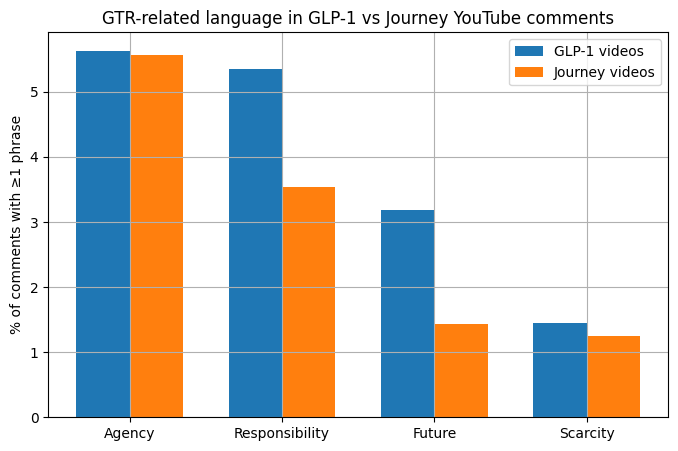

In [13]:
# UPDATED PLOT CELL — use percentage summary

labels = ["Agency", "Responsibility", "Future", "Scarcity"]
glp_vals  = [
    summary_df.loc[summary_df["group"]=="GLP-1", "pct_agency"].iloc[0],
    summary_df.loc[summary_df["group"]=="GLP-1", "pct_resp"].iloc[0],
    summary_df.loc[summary_df["group"]=="GLP-1", "pct_future"].iloc[0],
    summary_df.loc[summary_df["group"]=="GLP-1", "pct_scarcity"].iloc[0],
]
jour_vals = [
    summary_df.loc[summary_df["group"]=="Journey", "pct_agency"].iloc[0],
    summary_df.loc[summary_df["group"]=="Journey", "pct_resp"].iloc[0],
    summary_df.loc[summary_df["group"]=="Journey", "pct_future"].iloc[0],
    summary_df.loc[summary_df["group"]=="Journey", "pct_scarcity"].iloc[0],
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, glp_vals, width, label='GLP-1 videos')
ax.bar(x + width/2, jour_vals, width, label='Journey videos')

ax.set_ylabel('% of comments with ≥1 phrase')
ax.set_title('GTR-related language in GLP-1 vs Journey YouTube comments')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


# Results

This study analyzed **16,263 YouTube comments** across two distinct categories of weight-related videos:  
(1) those focused on **GLP-1 medications** (e.g., Ozempic, Wegovy), and  
(2) **traditional weight-loss journey** content centered on lifestyle changes.  
The analysis used a lexicon-based coding approach to identify linguistic indicators of **agency**, **responsibility**, **future orientation**, and **cognitive scarcity**, four dimensions central to the developing **Generalized Temporal Responsibility (GTR)** framework.

## Quantitative Findings

### Comment Volume
| Group | Total Comments |
|-------|----------------|
| GLP-1 | 8,932 |
| Journey | 7,331 |

The GLP-1 dataset was slightly larger, largely due to several high-engagement news videos.

### Frequency of GTR Dimensions

| Group | Agency | Responsibility | Future | Scarcity |
|-------|--------|----------------|--------|----------|
| GLP-1 (n=8,932) | 503 (5.63%) | 478 (5.35%) | 285 (3.19%) | 130 (1.46%) |
| Journey (n=7,331) | 408 (5.57%) | 259 (3.53%) | 105 (1.43%) | 92 (1.25%) |

### Statistical Tests (Two-Proportion Z-Tests)

- **Agency:** No significant difference  
  *z = 0.18, p = .855*  
- **Responsibility:** Significantly higher in GLP-1 comments  
  *z = 5.55, p < .001*  
- **Future Orientation:** Strongly higher in GLP-1 comments  
  *z = 7.29, p < .001*  
- **Scarcity:** No significant difference  
  *z = 1.10, p = .273*

### KWIC (Qualitative Excerpts)

To complement the quantitative analysis, a **Key Word In Context (KWIC)** search was used to examine the semantic and narrative patterns surrounding the target phrases. Ten examples per category were extracted for each phrase (“I should,” “future,” “I can,” “overwhelmed”). These samples revealed clear thematic differences between the discourse communities.

---

# Discussion

The results highlight distinct psychological and discursive patterns across the two online communities and offer preliminary empirical support for the **GTR framework**. The GTR model proposes that preventive behavior varies systematically across individuals and populations based on how they frame personal agency, moral/clinical obligation, and temporal orientation—shaped by cognitive load, social norms, and medicalization.

## Responsibility Framing: Moral Duty vs. Clinical Obligation

Responsibility language was significantly more common in GLP-1 discussions.  
KWIC excerpts reveal **two different meanings of responsibility**:

- **GLP-1:** “Should” reflects *medical management*  
  - “My doctor says I should…”, “I should have read side effects first.”
- **Journey:** “Should” reflects *self-judgment and morality*  
  - “I should be eating better”, “I should be doing more for my family.”

This suggests that **medicalization externalizes responsibility**, shifting it from self-discipline to risk–benefit calculations mediated by clinicians.  
This aligns with GTR: responsibility is not fixed; it shifts across domains.

## Future Orientation: Long-Term Health vs. Motivational Horizon

Future-oriented language was overwhelmingly more common in GLP-1 discourse.  
KWIC patterns show:

- GLP-1 commenters discuss **future health risks, long-term consequences, generational concerns**
- Journey commenters use “future” for **encouragement** or **progress updates**

This reflects a **temporal horizon shift**:
- GLP-1: forward-looking, risk-based, medical time horizon  
- Journey: shorter-term cycles of motivation  

GTR predicts this: cognitive load and lifestyle complexity compress future thinking unless external supports (like medications) extend it.

## Agency: Comparable Frequency, Divergent Meaning

Although agency frequency was similar statistically, KWIC reveals **two different kinds of agency**:

- **GLP-1:** agency located in the *body* (“I can’t eat as much on this dose”).  
- **Journey:** agency located in *self-control* (“I can’t stick to the plan”).

Thus, agency is **domain-specific**, not a universal trait.

## Scarcity: Present Only in Journey Discourse

While scarcity phrases were not statistically different, KWIC shows scarcity almost exclusively in journey comments, e.g.:

- “I’m overwhelmed with everything I need to do.”

GLP-1 comments rarely mentioned overwhelm.  
This suggests that GLP-1 medications may reduce the cognitive burden of behavior change—another form of “outsourced” temporal responsibility.

### Reconciling A Priori Predictions With Empirical Patterns
The results also prompted a re-examination of the GTR-based expectations formed prior to analysis. Because lifestyle change requires consistent self-regulation, I initially predicted that journey commenters would express more self-directed responsibility (“I should”), stronger perceived agency (“I can”), and more explicit references to long-term planning (“future,” “years from now”). Instead, GLP-1 discussions contained significantly more responsibility and future-oriented language.

This reversal offers an important theoretical insight: in medicalized contexts, responsibility becomes *externalized* (mediated by physicians, protocols, or clinical expectations), and temporal reasoning becomes *expanded* (anchored in medical timelines and risk projections). Meanwhile, journey commenters expressed greater cognitive scarcity and emotional overwhelm — consistent with a high self-regulatory burden and limited executive bandwidth.

The mismatch between prediction and outcome strengthens the GTR framework by demonstrating that agency, responsibility, and temporal orientation are not fixed traits but highly context-dependent linguistic constructs that shift across social and medical landscapes.




# Conclusion

This exploratory analysis of YouTube comments reveals distinct psychological and discursive differences between GLP-1–related videos and traditional weight-loss journey videos. While I initially expected journey discourse to show more responsibility, agency, and future-oriented thinking, the empirical results suggest a different pattern: GLP-1 comments contained significantly more responsibility and future-oriented language. This shift aligns with the idea that medicalization extends temporal horizons and reframes responsibility from a moral struggle (“I should try harder”) to a clinical task (“my doctor says I should…”).

Journey comments, by contrast, displayed stronger emotional burden and cognitive scarcity, consistent with the heavy self-regulatory demands of lifestyle-based weight loss. Although both groups used agency-related language at similar rates, KWIC analysis demonstrated that the *meaning* of agency differed across contexts—further reinforcing GTR’s premise that agency and responsibility are domain-specific constructs.

Together, these findings support the Generalized Temporal Responsibility (GTR) framework and suggest that preventive behavior—and the discourse surrounding it—reflects deeper psychological dynamics shaped by medical, cultural, and cognitive environments.

## Limitations

This analysis is exploratory and has several limitations.  
First, KWIC excerpts were limited to the top 10 context windows per keyword; expanding this sample would support deeper thematic coding. Second, the dataset is restricted to YouTube and specific search queries, which may bias the discourse toward certain demographics or content styles. Third, lexicon-based counting captures the presence of key phrases but cannot fully capture semantic nuance; future work should incorporate embedding-based or transformer-based methods. Finally, the analysis is cross-sectional, preventing examination of how discourse evolves over time.

Despite these limitations, the patterns identified here provide a strong foundation for more comprehensive analyses in future work.

## Key Takeaways
1. **GLP-1 discourse is more clinically anchored, future-oriented, and responsibility-focused.**
2. **Journey discourse reveals more emotional burden, moral framing, and cognitive scarcity.**
3. **Agency is expressed differently across groups, even when frequency is similar.**
4. **KWIC analysis provides essential qualitative depth that complements statistical findings.**

## Future Directions
- **Expanded KWIC sampling** — examining larger, randomly sampled context windows for each keyword to enable richer thematic interpretation.
- **Larger cross-platform datasets** (Reddit, TikTok, X/Twitter) to test generalizability.
- **Richer linguistic lexicons or transformer-based semantic modeling** for deeper semantic analysis.
- **Predictive GTR-based classification models** connecting discursive patterns to behavioral constructs.
- **Systems modeling of preventive behavior** to map interactions among agency, scarcity, medicalization, and temporal reasoning.
- **Cross-cultural comparisons (U.S. vs France vs Japan)** to investigate whether temporal responsibility patterns differ across cultural contexts.

These findings offer a strong foundation for expanding the GTR framework in BDS capstone projects, demonstrating how digital trace data can enrich theory-building in behavioral science.


##  Planned Module 7 Proficient Expansion


The next stage of this project will integrate transformer-based topic
modeling (BERTopic) to extract deeper semantic themes across both
datasets. This will allow comparison of not only lexical indicators of
GTR dimensions but also emergent topic structures, offering a richer
representation of how GLP-1 and Journey communities differ in responsibility,
agency, and temporal reasoning.


In [19]:
yt_df.to_csv("module_07.csv", index=False)
